# MSCViT (MSCViT-T) -- Figshare 4-Class (224x224, 35 epochs, trained from scratch, NO early stopping)
Same data pipeline as the other Figshare runs in this comparison: all Figshare images pooled from its `training images` / `validation images` / `test images` folders, shuffled, and re-split stratified **60% train / 20% validation / 20% test** (`random_state=42`). 4 classes: adenocarcinoma, squamous_cell_carcinoma, large_cell_carcinoma, normal.

**Specifications for this run:**
- Image size: **224x224**
- Batch size: **16**
- Epochs: **35, always runs the full 35 -- no early stopping**
- Optimizer: **Adam, learning_rate=5e-4**
- **Trained from scratch (no pretrained weights)** -- every parameter is randomly initialized.
- **No data augmentation**, **no class weighting**, and **no ImageNet normalization** (`Resize` + `ToTensor` only, consistent with the reference notebook this model was copied from).

**Implementation note:** the MSCViT model code (config dict, `ConvStem`, `DWConv`, `LFE`, `ChannelMixer`, `MSCBlock`, `Stage`, `MSCViT`) is carried over **verbatim** from the reference notebook you supplied (`Mobile-exp120-mscvit-imbalance-pneu-dataset.ipynb`), only `NUM_CLASSES`/`DEVICE` wiring changed to fit this pipeline. Default variant is `MSCViT-T` (lightest of the 3 configs in that notebook); switch `MSCVIT_VARIANT` in the model cell to `"MSCViT-XS"` or `"MSCViT-S"` for a heavier ablation point.

## 0. Explore /kaggle/input

In [5]:
import os

max_depth = 4
base_depth = "/kaggle/input".count(os.sep)
for dirpath, dirnames, filenames in os.walk("/kaggle/input"):
    depth = dirpath.count(os.sep) - base_depth
    if depth > max_depth:
        dirnames[:] = []
        continue
    indent = "  " * depth
    print(f"{indent}{os.path.basename(dirpath) or dirpath}/  [{len(filenames)} files]  {filenames[:2]}")

input/  [0 files]  []


## 1. Install + Imports
No extra package needed for the model itself -- MSCViT is plain `torch.nn` code, no `timm`/`torchvision` model classes involved.

In [6]:
# no extra install needed -- MSCViT is defined from scratch with plain torch.nn below

In [7]:
import os
import zipfile
import requests

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

TARGET_CLASSES = ['adenocarcinoma', 'squamous_cell_carcinoma', 'large_cell_carcinoma', 'normal']
CLASS_TO_IDX = {c: i for i, c in enumerate(TARGET_CLASSES)}
NUM_CLASSES = len(TARGET_CLASSES)

IMG_SIZE = (224, 224)
BATCH_SIZE = 16
EPOCHS = 35
LEARNING_RATE = 5e-4
CHECKPOINT_PATH = "best_mscvit_figshare_224.pt"

Using device: cuda


## 2. Figshare -- Download

In [8]:
FIGSHARE_DOWNLOAD_URL = "https://ndownloader.figshare.com/files/52627007"
FIGSHARE_ZIP = "/kaggle/working/lung_cancer_dataset.zip"
FIGSHARE_DIR = "/kaggle/working/lung_cancer_dataset"
EXPECTED_SIZE = 138394807

if os.path.exists(FIGSHARE_ZIP) and os.path.getsize(FIGSHARE_ZIP) != EXPECTED_SIZE:
    os.remove(FIGSHARE_ZIP)

if not os.path.exists(FIGSHARE_ZIP):
    print("Downloading Figshare dataset...")
    resp = requests.get(FIGSHARE_DOWNLOAD_URL, stream=True, timeout=120, headers={"User-Agent": "Mozilla/5.0"})
    with open(FIGSHARE_ZIP, "wb") as f:
        for chunk in resp.iter_content(chunk_size=8192):
            if chunk:
                f.write(chunk)
    size = os.path.getsize(FIGSHARE_ZIP)
    print("Downloaded size:", size, " Matches expected:", size == EXPECTED_SIZE)

if not os.path.exists(FIGSHARE_DIR):
    print("Extracting...")
    with zipfile.ZipFile(FIGSHARE_ZIP, 'r') as z:
        z.extractall(FIGSHARE_DIR)
    print("Done.")

## 3. Pool ALL images, then stratified 60/20/20 split

In [9]:
FIGSHARE_LABEL_MAP = {
    "adenocarcinoma": "adenocarcinoma",
    "squamous.cell.carcinoma": "squamous_cell_carcinoma",
    "large.cell.carcinoma": "large_cell_carcinoma",
    "normal": "normal",
}

def build_figshare_df_from_folder(folder_name):
    split_dir = None
    for dirpath, dirnames, filenames in os.walk(FIGSHARE_DIR):
        if folder_name in dirnames:
            split_dir = os.path.join(dirpath, folder_name)
            break
    if split_dir is None:
        print(f"!! Could not find '{folder_name}'")
        return pd.DataFrame()
    records = []
    for folder in os.listdir(split_dir):
        folder_path = os.path.join(split_dir, folder)
        if not os.path.isdir(folder_path):
            continue
        raw_prefix = folder.split('_')[0]
        label = FIGSHARE_LABEL_MAP.get(raw_prefix)
        if label is None:
            continue
        for fname in os.listdir(folder_path):
            records.append({"filepath": os.path.join(folder_path, fname), "label": label})
    return pd.DataFrame(records)

_train_part = build_figshare_df_from_folder("training images")
_val_part   = build_figshare_df_from_folder("validation images")
_test_part  = build_figshare_df_from_folder("test images")

full_pool = pd.concat([_train_part, _val_part, _test_part], ignore_index=True)
full_pool = full_pool.sample(frac=1.0, random_state=42).reset_index(drop=True)

train_df, temp_df = train_test_split(
    full_pool, train_size=0.60, stratify=full_pool["label"], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, train_size=0.50, stratify=temp_df["label"], random_state=42
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train size:", len(train_df), " Val size:", len(val_df), " Test size:", len(test_df))
print("\nTrain class balance:\n", train_df["label"].value_counts())
print("\nVal class balance:\n", val_df["label"].value_counts())
print("\nTest class balance:\n", test_df["label"].value_counts())

Train size: 600  Val size: 200  Test size: 200

Train class balance:
 label
adenocarcinoma             203
squamous_cell_carcinoma    156
normal                     129
large_cell_carcinoma       112
Name: count, dtype: int64

Val class balance:
 label
adenocarcinoma             67
squamous_cell_carcinoma    52
normal                     43
large_cell_carcinoma       38
Name: count, dtype: int64

Test class balance:
 label
adenocarcinoma             68
squamous_cell_carcinoma    52
normal                     43
large_cell_carcinoma       37
Name: count, dtype: int64


## 4. PyTorch Dataset/DataLoader -- no augmentation, no normalization (trained from scratch)
`Resize((224,224))` + `ToTensor()` only -- no ImageNet mean/std normalization, matching the reference MSCViT notebook and the from-scratch-CNN convention used for MSA-Dense-Net elsewhere in this comparison. No random augmentation (no flips, crops, jitter, etc).

In [10]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

class LungCTDataset(Dataset):
    """Reads (filepath, label) rows from a pandas dataframe, opens each image with PIL,
    applies the shared (non-random) transform, and returns (image_tensor, label_index)."""
    def __init__(self, df, class_to_idx, transform=None):
        self.df = df.reset_index(drop=True)
        self.class_to_idx = class_to_idx
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["filepath"]).convert("RGB")
        if self.transform is not None:
            img = self.transform(img)
        label = self.class_to_idx[row["label"]]
        return img, label

train_dataset = LungCTDataset(train_df, CLASS_TO_IDX, transform=transform)
val_dataset   = LungCTDataset(val_df,   CLASS_TO_IDX, transform=transform)
test_dataset  = LungCTDataset(test_df,  CLASS_TO_IDX, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print("Train batches:", len(train_loader), " Val batches:", len(val_loader), " Test batches:", len(test_loader))

Train batches: 38  Val batches: 13  Test batches: 13


## 5. Model -- MSCViT (MSCViT-T), trained from scratch
Custom **MSCViT** architecture, carried over verbatim from the reference implementation (`Mobile-exp120-mscvit-imbalance-pneu-dataset.ipynb`) -- a lightweight hybrid CNN: a 3-conv stem, then 4 stages each starting with a stride-2 downsampling conv, followed by `P` repeated blocks of `LFE` (depthwise-separable local feature extraction with a residual) + `R` stacked `ChannelMixer` (1x1-conv MLP) sub-blocks with residual connections, ending in global average pooling and a single linear classification head. Built and trained **entirely from scratch** -- no pretrained weights.

**Note on the attention mechanism:** in this reference implementation the paper's Lightweight Multi-Scale Self-Attention (LMSSA) is realized as `R` repeated `ChannelMixer` (1x1-conv) blocks per stage rather than literal multi-head self-attention with per-head token-reduction ratios -- carried over as-is from the notebook you supplied, since that's the exact architecture to reproduce for this ablation. `MSCVIT_VARIANT` is set at the top of the model cell (`"MSCViT-T"` / `"MSCViT-XS"` / `"MSCViT-S"`) if you want to swap in a larger variant.

In [11]:
MSCVIT_VARIANT = "MSCViT-T"  # "MSCViT-T" (lightest) / "MSCViT-XS" / "MSCViT-S" -- swap here for the ablation

MSCViT_CONFIGS = {
    "MSCViT-T": {
        "stem_channels": 16,
        "stages": [
            {"C": 32,  "P": 3, "R": 4},
            {"C": 64,  "P": 3, "R": 3},
            {"C": 128, "P": 5, "R": 2},
            {"C": 256, "P": 5, "R": 1},
        ],
    },
    "MSCViT-XS": {
        "stem_channels": 24,
        "stages": [
            {"C": 48,  "P": 3, "R": 4},
            {"C": 96,  "P": 3, "R": 3},
            {"C": 192, "P": 5, "R": 2},
            {"C": 384, "P": 5, "R": 1},
        ],
    },
    "MSCViT-S": {
        "stem_channels": 32,
        "stages": [
            {"C": 64,  "P": 3, "R": 4},
            {"C": 128, "P": 3, "R": 3},
            {"C": 256, "P": 5, "R": 2},
            {"C": 512, "P": 5, "R": 1},
        ],
    },
}

class ConvStem(nn.Module):
    def __init__(self, out_channels):
        super().__init__()
        self.stem = nn.Sequential(
            # First conv: downsample
            nn.Conv2d(3, out_channels, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            # Repeat conv (x2) with stride = 1
            nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.stem(x)

class DWConv(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dw = nn.Conv2d(dim, dim, 3, padding=1, groups=dim, bias=False)
        self.pw = nn.Conv2d(dim, dim, 1, bias=False)
        self.bn = nn.BatchNorm2d(dim)
        self.act = nn.ReLU(inplace=True)

    def forward(self, x):
        return self.act(self.bn(self.pw(self.dw(x))))

class LFE(nn.Module):
    """Local Feature Extraction -- depthwise-separable conv block."""
    def __init__(self, dim):
        super().__init__()
        self.conv = DWConv(dim)

    def forward(self, x):
        return self.conv(x)

class ChannelMixer(nn.Module):
    """1x1-conv MLP-style channel mixer (stands in for the multi-scale
    self-attention token mixer, applied `R` times per stage)."""
    def __init__(self, dim, expansion=2):
        super().__init__()
        hidden = dim * expansion
        self.fc1 = nn.Conv2d(dim, hidden, 1, bias=False)
        self.act = nn.GELU()
        self.fc2 = nn.Conv2d(hidden, dim, 1, bias=False)
        self.bn = nn.BatchNorm2d(dim)

    def forward(self, x):
        return self.bn(self.fc2(self.act(self.fc1(x))))

class MSCBlock(nn.Module):
    def __init__(self, dim, attn_depth):
        super().__init__()
        self.lfe = LFE(dim)
        self.mixers = nn.ModuleList([ChannelMixer(dim) for _ in range(attn_depth)])

    def forward(self, x):
        x = x + self.lfe(x)
        for m in self.mixers:
            x = x + m(x)
        return x

class Stage(nn.Module):
    def __init__(self, in_channels, out_channels, num_blocks, attn_depth):
        super().__init__()
        self.downsample = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
        )
        self.blocks = nn.ModuleList([MSCBlock(out_channels, attn_depth) for _ in range(num_blocks)])

    def forward(self, x):
        x = self.downsample(x)
        for blk in self.blocks:
            x = blk(x)
        return x

class MSCViT(nn.Module):
    def __init__(self, variant="MSCViT-T", num_classes=1000, global_pool="avg"):
        super().__init__()
        cfg = MSCViT_CONFIGS[variant]
        self.stem = ConvStem(cfg["stem_channels"])

        in_ch = cfg["stem_channels"]
        self.stages = nn.ModuleList()
        for s in cfg["stages"]:
            self.stages.append(Stage(in_ch, s["C"], s["P"], s["R"]))
            in_ch = s["C"]

        self.head = nn.Linear(in_ch, num_classes) if num_classes > 0 else nn.Identity()
        self.global_pool = global_pool

    def forward(self, x):
        x = self.stem(x)
        for stage in self.stages:
            x = stage(x)
        x = x.mean((2, 3)) if self.global_pool == "avg" else x.amax((2, 3))
        return self.head(x)

model = MSCViT(MSCVIT_VARIANT, num_classes=NUM_CLASSES).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters())
print(f"{MSCVIT_VARIANT} -- total params: {n_params:,}")
print(model.head)

MSCViT-T -- total params: 3,017,780
Linear(in_features=256, out_features=4, bias=True)


## 6. FLOPs -- cost of training from scratch (image-wise and batch-wise, dynamic multiplier)
Forward-pass FLOPs are measured directly with `fvcore`'s `FlopCountAnalysis` (installed below), for a single `(1,3,224,224)` image and for a full `(BATCH_SIZE,3,224,224)` batch. `trainable_fraction` is computed dynamically from `model.parameters()` -- since MSCViT is trained entirely from scratch, this comes out to `1.0`, giving a `1 + 2*trainable_fraction = 3x` training-FLOPs-vs-forward-FLOPs multiplier, same dynamic-multiplier methodology used throughout this comparison.

**Caveat on FLOP counting:** `fvcore`'s `FlopCountAnalysis` only counts multiply-accumulate FLOPs for operators it has explicit handlers for (conv, linear/matmul, batchnorm, etc). `flop_analyzer.unsupported_ops_warnings(False)` suppresses the per-op warnings but any skipped ops are NOT added back in, so the numbers below should be read as a **lower-bound estimate**, not an exact figure -- useful for relative comparison against the other architectures in this repo (all counted the same way).

In [12]:
!pip install -q fvcore

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.6/129.6 kB 7.7 MB/s eta 0:00:00


In [13]:
from fvcore.nn import FlopCountAnalysis

def get_flops(pt_model, batch_size):
    pt_model.eval()
    dummy_input = torch.randn(batch_size, 3, 224, 224, device=DEVICE)
    with torch.no_grad():
        analyzer = FlopCountAnalysis(pt_model, dummy_input)
        analyzer.unsupported_ops_warnings(False)
        analyzer.uncalled_modules_warnings(False)
        total_flops = analyzer.total()
    pt_model.train()
    return total_flops

# --- Trainable-vs-frozen split, read dynamically off the model ---
trainable_param_count = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_param_count = sum(p.numel() for p in model.parameters())
trainable_fraction = trainable_param_count / total_param_count

BACKWARD_MULTIPLIER = 2 * trainable_fraction
TOTAL_MULTIPLIER = 1 + BACKWARD_MULTIPLIER  # TRAINING_FLOPS_MULTIPLIER

print(f"Trainable params: {trainable_param_count:,} / {total_param_count:,}  (trainable_fraction={trainable_fraction:.4f})")
print(f"Derived training FLOPs multiplier: {TOTAL_MULTIPLIER:.4f}x forward\n")

# --- FORWARD pass FLOPs (measured directly, once per image and once per batch) ---
flops_per_image_fwd = get_flops(model, batch_size=1)
flops_per_batch_fwd = get_flops(model, batch_size=BATCH_SIZE)

# --- BACKWARD pass FLOPs (derived, not separately traced) ---
flops_per_image_bwd = flops_per_image_fwd * BACKWARD_MULTIPLIER
flops_per_batch_bwd = flops_per_batch_fwd * BACKWARD_MULTIPLIER

# --- TOTAL training FLOPs (forward + backward) ---
flops_per_image_total = flops_per_image_fwd * TOTAL_MULTIPLIER
flops_per_batch_total = flops_per_batch_fwd * TOTAL_MULTIPLIER

steps_per_epoch = len(train_df) // BATCH_SIZE
flops_per_epoch_total = flops_per_batch_total * steps_per_epoch
flops_full_run_total = flops_per_epoch_total * EPOCHS  # exact -- no early stopping, always runs all EPOCHS

print("=== FORWARD ===")
print(f"Per image:  {flops_per_image_fwd:,}  (~{flops_per_image_fwd/1e9:.3f} GFLOPs)")
print(f"Per batch (batch_size={BATCH_SIZE}):  {flops_per_batch_fwd:,}  (~{flops_per_batch_fwd/1e9:.3f} GFLOPs)")

print("\n=== BACKWARD ===")
print(f"Per image:  {flops_per_image_bwd:,.0f}  (~{flops_per_image_bwd/1e9:.3f} GFLOPs)")
print(f"Per batch (batch_size={BATCH_SIZE}):  {flops_per_batch_bwd:,.0f}  (~{flops_per_batch_bwd/1e9:.3f} GFLOPs)")

print("\n=== TOTAL (forward + backward) ===")
print(f"Per image:  {flops_per_image_total:,.0f}  (~{flops_per_image_total/1e9:.3f} GFLOPs)")
print(f"Per batch (batch_size={BATCH_SIZE}):  {flops_per_batch_total:,.0f}  (~{flops_per_batch_total/1e9:.3f} GFLOPs)")
print(f"\nSteps per epoch: {steps_per_epoch}  (train set size {len(train_df)} / batch size {BATCH_SIZE})")
print(f"Per epoch:  {flops_per_epoch_total:,.0f}  (~{flops_per_epoch_total/1e12:.3f} TFLOPs)")
print(f"Full {EPOCHS}-epoch run (exact -- no early stopping):  {flops_full_run_total:,.0f}  (~{flops_full_run_total/1e15:.3f} PFLOPs)")

Trainable params: 3,017,780 / 3,017,780  (trainable_fraction=1.0000)
Derived training FLOPs multiplier: 3.0000x forward

=== FORWARD ===
Per image:  647,384,320  (~0.647 GFLOPs)
Per batch (batch_size=16):  10,358,149,120  (~10.358 GFLOPs)

=== BACKWARD ===
Per image:  1,294,768,640  (~1.295 GFLOPs)
Per batch (batch_size=16):  20,716,298,240  (~20.716 GFLOPs)

=== TOTAL (forward + backward) ===
Per image:  1,942,152,960  (~1.942 GFLOPs)
Per batch (batch_size=16):  31,074,447,360  (~31.074 GFLOPs)

Steps per epoch: 37  (train set size 600 / batch size 16)
Per epoch:  1,149,754,552,320  (~1.150 TFLOPs)
Full 35-epoch run (exact -- no early stopping):  40,241,409,331,200  (~0.040 PFLOPs)


## 7. Training loop -- NO early stopping, all {EPOCHS} epochs, checkpoint best val_accuracy
Standard PyTorch training loop: `CrossEntropyLoss()` (no class weights), `Adam(lr=5e-4)`. Every epoch runs; there is no early-stopping check anywhere in this loop -- all 35 epochs always run. The checkpoint with the highest `val_accuracy` so far is saved to `best_mscvit_figshare_224.pt` after each epoch.

In [14]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc = 0.0

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    running_correct = 0
    running_total = 0
    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        running_correct += (preds == labels).sum().item()
        running_total += images.size(0)

    train_loss = running_loss / running_total
    train_acc = running_correct / running_total

    model.eval()
    val_loss_sum = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss_sum += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += images.size(0)

    val_loss = val_loss_sum / val_total
    val_acc = val_correct / val_total

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS}  train_loss={train_loss:.4f} train_acc={train_acc:.4f}  "
          f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), CHECKPOINT_PATH)
        print(f"  -> New best val_accuracy {val_acc:.4f}, checkpoint saved to {CHECKPOINT_PATH}")

print(f"\nTraining complete -- ran all {EPOCHS} epochs (no early stopping). Best val_accuracy: {best_val_acc:.4f}")

Epoch 1/35  train_loss=1.1537 train_acc=0.5067  val_loss=2.5942 val_acc=0.2600
  -> New best val_accuracy 0.2600, checkpoint saved to best_mscvit_figshare_224.pt
Epoch 2/35  train_loss=0.8658 train_acc=0.6217  val_loss=1.1314 val_acc=0.4450
  -> New best val_accuracy 0.4450, checkpoint saved to best_mscvit_figshare_224.pt
Epoch 3/35  train_loss=0.6462 train_acc=0.7350  val_loss=1.2209 val_acc=0.6000
  -> New best val_accuracy 0.6000, checkpoint saved to best_mscvit_figshare_224.pt
Epoch 4/35  train_loss=0.6754 train_acc=0.7050  val_loss=1.5175 val_acc=0.5750
Epoch 5/35  train_loss=0.5623 train_acc=0.7817  val_loss=1.8361 val_acc=0.4700
Epoch 6/35  train_loss=0.3512 train_acc=0.8733  val_loss=1.5047 val_acc=0.5900
Epoch 7/35  train_loss=0.3653 train_acc=0.8567  val_loss=1.1087 val_acc=0.6700
  -> New best val_accuracy 0.6700, checkpoint saved to best_mscvit_figshare_224.pt
Epoch 8/35  train_loss=0.2866 train_acc=0.9033  val_loss=3.1510 val_acc=0.4600
Epoch 9/35  train_loss=0.3135 train_

## 8. Plot train/val loss + accuracy

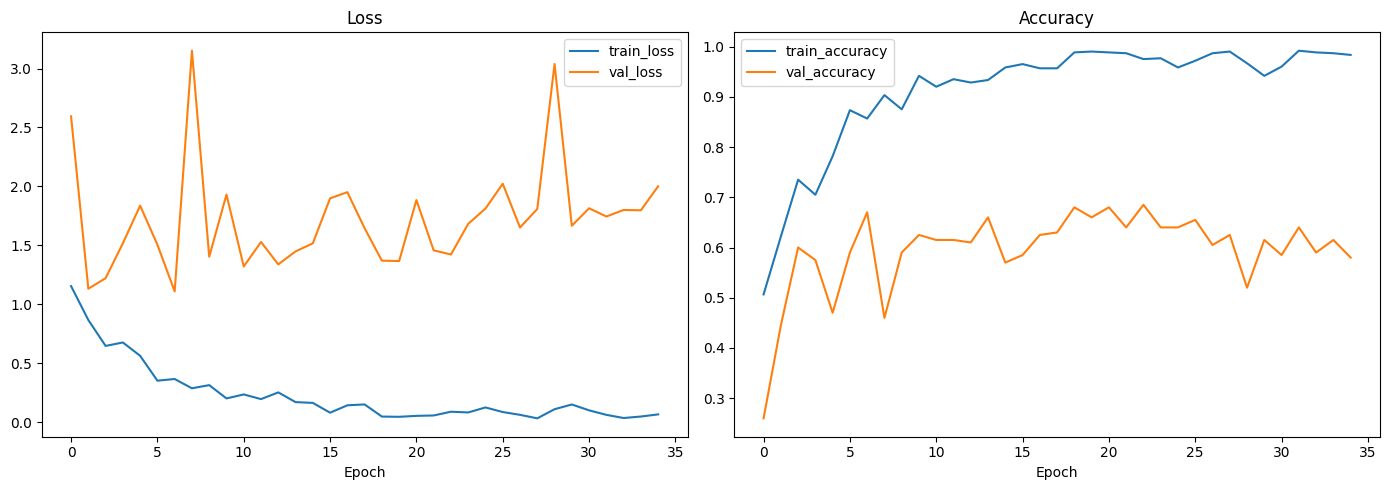

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history["train_loss"], label="train_loss")
axes[0].plot(history["val_loss"], label="val_loss")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history["train_acc"], label="train_accuracy")
axes[1].plot(history["val_acc"], label="val_accuracy")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.savefig("/kaggle/working/training_curves_mscvit_figshare_224.png", dpi=150)
plt.show()

## 9. Final evaluation on TEST set (load best checkpoint)

Test loss: 1.1702  Test accuracy: 0.6650

Classification Report:
                         precision    recall  f1-score   support

         adenocarcinoma     0.5455    0.7941    0.6467        68
squamous_cell_carcinoma     0.5312    0.3269    0.4048        52
   large_cell_carcinoma     0.8333    0.5405    0.6557        37
                 normal     0.9333    0.9767    0.9545        43

               accuracy                         0.6650       200
              macro avg     0.7108    0.6596    0.6654       200
           weighted avg     0.6784    0.6650    0.6517       200

Test macro F1: 0.6654

Prediction distribution:
adenocarcinoma             99
normal                     45
squamous_cell_carcinoma    32
large_cell_carcinoma       24
Name: count, dtype: int64


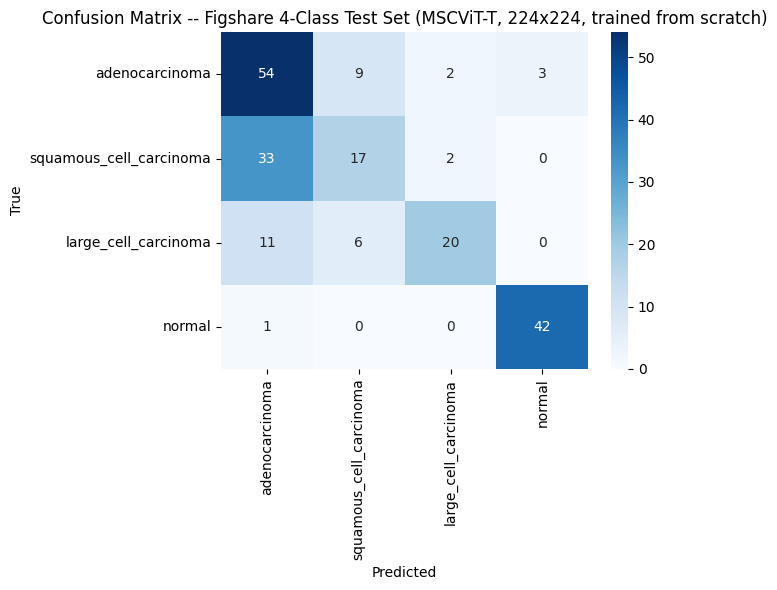


MSCViT-T (Figshare 4-Class, 224x224, trained from scratch) test accuracy: 66.50%


In [16]:
model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=DEVICE))
model.eval()

test_loss_sum = 0.0
test_correct = 0
test_total = 0
y_true_idx = []
y_pred_idx = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = model(images)
        loss = criterion(outputs, labels)
        test_loss_sum += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        test_correct += (preds == labels).sum().item()
        test_total += images.size(0)
        y_true_idx.extend(labels.cpu().numpy().tolist())
        y_pred_idx.extend(preds.cpu().numpy().tolist())

test_loss = test_loss_sum / test_total
test_acc = test_correct / test_total
print(f"Test loss: {test_loss:.4f}  Test accuracy: {test_acc:.4f}")

print("\nClassification Report:")
print(classification_report(y_true_idx, y_pred_idx, target_names=TARGET_CLASSES, digits=4))

test_macro_f1 = f1_score(y_true_idx, y_pred_idx, average="macro")
print(f"Test macro F1: {test_macro_f1:.4f}")

print("\nPrediction distribution:")
print(pd.Series(y_pred_idx).map({i: c for i, c in enumerate(TARGET_CLASSES)}).value_counts())

cm = confusion_matrix(y_true_idx, y_pred_idx)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=TARGET_CLASSES, yticklabels=TARGET_CLASSES)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix -- Figshare 4-Class Test Set (MSCViT-T, 224x224, trained from scratch)")
plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrix_mscvit_figshare_224.png", dpi=150)
plt.show()

print(f"\nMSCViT-T (Figshare 4-Class, 224x224, trained from scratch) test accuracy: {test_acc*100:.2f}%")